# 04 - Lake inventory and data quality

What is actually inside the parquet lakes, and where the raw data misbehaves.
Everything here reads from disk only: no API calls, no network.

The notebook answers four questions:

1. **What is on disk?** Every lake, its layout, file count, size and row count.
2. **What does it cover?** Tickers and rows per year, listings and delistings, the trading calendar.
3. **Where is it wrong?** Impossible bars, empty tickers, zero prices, duplicated sessions.
4. **Do the adjustments explain the extremes?** The biggest overnight moves before and after adjustment.

Cost: a few minutes. The day lake is read in full (46 M rows); the minute lake is
touched only through parquet metadata and its per-day index sidecars.

## 1. Configuration

`POLYGON_LAKE_ROOT` points at the lake root. Set it in the environment to run this
against a different machine's lakes; nothing below hard-codes a path.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.compute as pc
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

LAKE = Path(os.environ.get("POLYGON_LAKE_ROOT", Path.home() / "local" / "parquet_lake"))
assert LAKE.is_dir(), f"lake root not found: {LAKE}  (set POLYGON_LAKE_ROOT)"

DAY_RAW = LAKE / "day" / "all"
DAY_ADJ = LAKE / "day_adj" / "all_adjusted"
MIN_RAW = LAKE / "minute" / "all"
MIN_ADJ = LAKE / "minute_adj" / "all_adjusted"

def data_files(root: Path) -> list[Path]:
    """Parquet data files of a lake: no `.idx.parquet` sidecars, no `manifest_*.json`."""
    return sorted(p for p in root.rglob("*.parquet") if not p.name.endswith(".idx.parquet"))

def read_lake(root: Path, columns: list[str]) -> pd.DataFrame:
    """Read a whole market-layout lake, dictionary encoding `ticker` so 33 k repeated symbols
    cost a few bytes a row instead of a python string each."""
    t = pq.read_table(data_files(root), columns=columns)
    i = t.schema.get_field_index("ticker")
    return t.set_column(i, "ticker", t.column("ticker").dictionary_encode()).to_pandas()

plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
print("lake root:", LAKE)

lake root: /Users/mengren/local/parquet_lake


## 2. What is on disk

Row counts come from the parquet footers, so this costs milliseconds per file and
never decodes a data page. Sidecar files (`*.idx.parquet`) are the per-ticker row
index of a market-layout minute day file; they are counted separately.

In [2]:
def lake_stats(root: Path) -> dict:
    """File count, bytes and row count for one lake, from parquet metadata only."""
    if not root.is_dir():
        return {"lake": root.name, "exists": False}
    data = data_files(root)
    side = list(root.rglob("*.idx.parquet"))
    depth = len(data[0].relative_to(root).parts) if data else 0
    return {
        "lake": str(root.relative_to(LAKE)),
        "layout": "market" if any(d.name[:4].isdigit() and len(d.name) == 4 for d in root.iterdir() if d.is_dir()) else "ticker",
        "period": {1: "year", 2: "month", 3: "day"}.get(depth, f"depth {depth}"),
        "files": len(data),
        "sidecars": len(side),
        "GB": round(sum(p.stat().st_size for p in data + side) / 2**30, 1),
        "rows": sum(pq.ParquetFile(p).metadata.num_rows for p in data),
    }

inventory = pd.DataFrame([lake_stats(r) for r in (DAY_RAW, DAY_ADJ, MIN_RAW, MIN_ADJ)])
inventory["rows"] = inventory["rows"].map("{:,}".format)
inventory["files"] = inventory["files"].map("{:,}".format)
inventory

,lake,layout,period,files,sidecars,GB,rows
0,day/all,market,month,264,0,0.8,"46,490,595"
1,day_adj/all_adjusted,market,month,264,0,2.4,"46,490,595"
2,minute/all,market,day,"5,517",5517,93.1,"7,042,253,913"
3,minute_adj/all_adjusted,market,day,"5,517",5517,218.7,"7,042,253,913"


Both granularities use the **market layout**: one file per period holding every ticker,
sorted ticker-major. The day lake partitions by month, the minute lake by day. The 5,517
minute sidecars mean every minute day file has its per-ticker row index, which is what
makes single-symbol reads cheap (notebook 06).

## 3. Loading the day lake

The whole unadjusted day lake fits in memory comfortably once `ticker` is dictionary
encoded. `datetime` is tz-aware US/Eastern in the unadjusted lakes, so the ET trading
date is just the normalised date.

In [3]:
day = read_lake(DAY_RAW, ["datetime", "ticker", "open", "high", "low", "close", "volume", "transactions"])
day["date"] = day["datetime"].dt.normalize().dt.tz_localize(None)
day["year"] = day["date"].dt.year
print(f"{len(day):,} rows x {day.shape[1]} cols, {day.memory_usage(deep=True).sum() / 2**30:.1f} GB in memory")
print(f"{day['ticker'].nunique():,} tickers, {day['date'].nunique():,} trading days, "
      f"{day['date'].min().date()} to {day['date'].max().date()}")
day.head(3)

46,490,595 rows x 10 cols, 3.1 GB in memory
33,833 tickers, 5,517 trading days, 2003-09-10 to 2025-08-13


,datetime,ticker,open,high,low,close,volume,transactions,date,year
0,2003-09-10 00:00:00-04:00,A,25.40,25.580,24.41,24.49,2869700,2301,2003-09-10,2003
1,2003-09-11 00:00:00-04:00,A,24.57,25.180,24.45,25.04,2075400,1907,2003-09-11,2003
2,2003-09-12 00:00:00-04:00,A,25.04,25.114,24.55,24.97,2017700,1542,2003-09-12,2003


## 4. Coverage through time

How many symbols the market carried each year, and how many rows that produced.

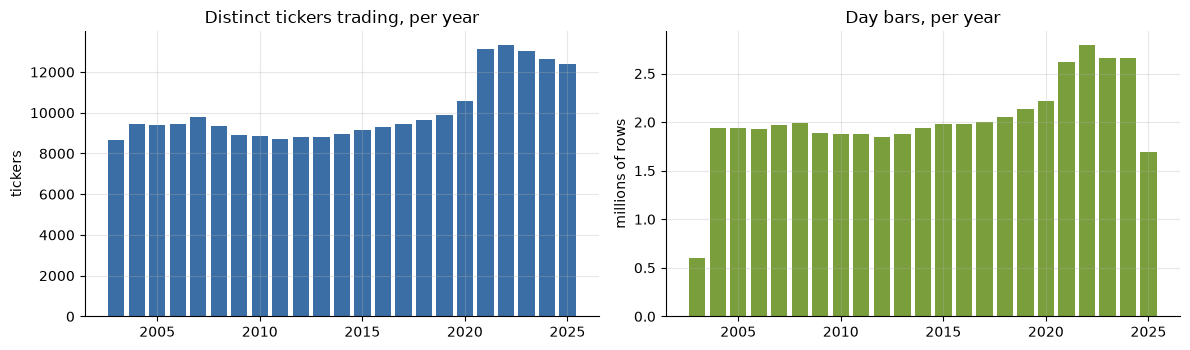

,rows,tickers,trading_days,dollar_vol
year,,,,
2003,"605,841",8657,79,291669066341
2004,"1,935,189",9445,252,971522516153
2005,"1,934,750",9398,252,1026410181815
2006,"1,932,790",9450,251,1210515593295
2007,"1,974,279",9798,251,1520874383841
2008,"1,995,235",9356,253,2232155486801
2009,"1,892,293",8888,252,2457386485132
2010,"1,876,075",8870,252,2131021777282
2011,"1,879,131",8728,252,1967457442210


In [4]:
per_year = day.groupby("year").agg(rows=("close", "size"), tickers=("ticker", "nunique"),
                                   trading_days=("date", "nunique"), dollar_vol=("volume", "sum"))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].bar(per_year.index, per_year["tickers"], color="#3b6ea5")
ax[0].set_title("Distinct tickers trading, per year"); ax[0].set_ylabel("tickers")
ax[1].bar(per_year.index, per_year["rows"] / 1e6, color="#7a9e3b")
ax[1].set_title("Day bars, per year"); ax[1].set_ylabel("millions of rows")
for a in ax:
    a.set_xlabel("")
fig.tight_layout(); plt.show()
per_year.assign(rows=lambda d: d["rows"].map("{:,}".format)).head(30)

The dip after 2008 and the climb from 2020 are real market history: delistings in the
crisis, then the SPAC and ETF boom. 2025 is a partial year (the flat files end in August).

## 5. Trading calendar

A market-wide day lake should have one file entry per NYSE session. Rather than pull an
exchange calendar, we check the two things that actually indicate a problem: sessions
whose spacing is wrong, and sessions where far fewer symbols traded than usual.

In [5]:
days = pd.Series(sorted(day["date"].unique()))
gaps = days.diff().dt.days
long_gaps = pd.DataFrame({"session": days[gaps > 4], "days_since_previous": gaps[gaps > 4]})
full_years = days.dt.year.value_counts().drop([days.dt.year.min(), days.dt.year.max()])
print(f"{len(days):,} sessions, {days.dt.year.nunique()} calendar years")
print(f"sessions per complete year: min {full_years.min()}, median {full_years.median():.0f}, max {full_years.max()}")
print(f"gaps longer than a long weekend: {len(long_gaps)}")
long_gaps.assign(session=lambda d: d["session"].dt.date)

5,517 sessions, 23 calendar years
sessions per complete year: min 250, median 252, max 253
gaps longer than a long weekend: 2


,session,days_since_previous
834,2007-01-03,5.0
2302,2012-10-31,5.0


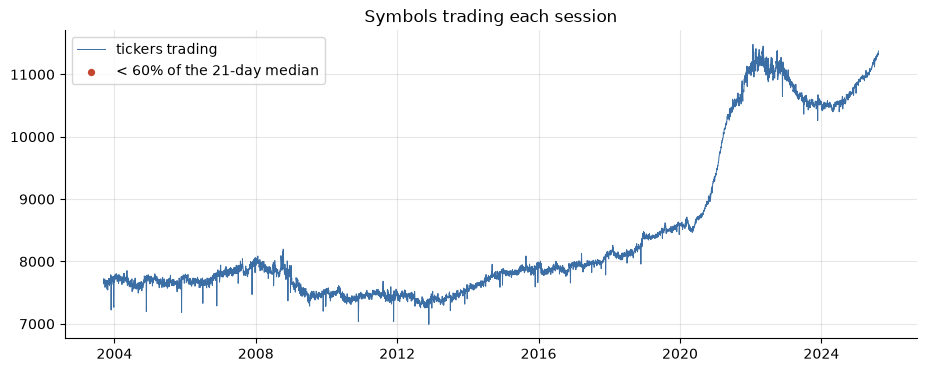

unusually thin sessions: 0


,tickers,pct_of_median
date,,


In [6]:
per_day = day.groupby("date")["ticker"].nunique()
med = per_day.rolling(21, center=True, min_periods=5).median()
thin = per_day[per_day < 0.6 * med]
fig, ax = plt.subplots()
ax.plot(per_day.index, per_day.values, lw=.7, color="#3b6ea5", label="tickers trading")
ax.scatter(thin.index, thin.values, s=18, color="#c4462f", zorder=3, label="< 60% of the 21-day median")
ax.set_title("Symbols trading each session"); ax.legend(loc="upper left"); plt.show()
print(f"unusually thin sessions: {len(thin)}")
thin.rename("tickers").to_frame().assign(pct_of_median=lambda d: (d["tickers"] / med[d.index]).round(2))

Every complete year has between 250 and 253 sessions, which is the correct NYSE count, and
no session is unusually thin: even the half days (the afternoon after Thanksgiving, Christmas
Eve) carry their full roster of symbols, because a shortened session still prints a day bar.

The two long gaps are real market closures, and finding exactly these two is a good sign:

- **2007-01-03** follows a four-day break: New Year plus 2 January, the national day of
  mourning for Gerald Ford.
- **2012-10-31** follows the two-day Hurricane Sandy closure of 29 and 30 October.

## 6. Data quality checks

Each check counts rows that are impossible or implausible on their face.

In [7]:
o, h, l, c, v = (day[k] for k in ("open", "high", "low", "close", "volume"))
checks = {
    "null ticker": day["ticker"].isna().sum(),
    "null or NaN close": c.isna().sum(),
    "close <= 0": (c <= 0).sum(),
    "any OHLC <= 0": ((o <= 0) | (h <= 0) | (l <= 0) | (c <= 0)).sum(),
    "high < low": (h < l).sum(),
    "close outside [low, high]": ((c < l) | (c > h)).sum(),
    "open outside [low, high]": ((o < l) | (o > h)).sum(),
    "volume == 0": (v == 0).sum(),
    "volume < 0": (v < 0).sum(),
    "transactions == 0": (day["transactions"] == 0).sum(),
    "duplicate (ticker, date)": day.duplicated(["ticker", "date"]).sum(),
}
quality = pd.DataFrame({"rows": pd.Series(checks)})
quality["share"] = (quality["rows"] / len(day)).map("{:.4%}".format)
quality["rows"] = quality["rows"].map("{:,}".format)
quality

,rows,share
null ticker,0,0.0000%
null or NaN close,0,0.0000%
close <= 0,0,0.0000%
any OHLC <= 0,0,0.0000%
high < low,0,0.0000%
"close outside [low, high]",0,0.0000%
"open outside [low, high]",0,0.0000%
volume == 0,"166,770",0.3587%
volume < 0,0,0.0000%
transactions == 0,"166,770",0.3587%


Every *bar-level* invariant holds: no crossed bars, no closes outside the day's range, no
non-positive prices. Zero-volume rows are a real Polygon artefact for symbols that printed a
quote but no trade, and they always carry zero transactions too.

The duplicate ticker-days are a genuine defect, and worth a section of their own.

### Duplicate ticker-days: a casing collision, and one bad source file

The first run of this notebook found **29,258** duplicated ticker-days across 90 symbols, and
tracing one back to the flat file showed why. **Polygon encodes the share class in the letter case
of a symbol**, and the ingester upper-cased: `AAp` — the Alcoa Inc. $3.75 preferred — became `AAP`,
Advance Auto Parts, and two securities' bars were interleaved into one series. `CpS`, `CHKp`,
`CpF` and 86 others the same.

`polygon_ingest` now stores the symbol exactly as Polygon spells it and these lakes were rebuilt.
What is left has a different cause.

In [8]:
dups = day[day.duplicated(["ticker", "date"], keep=False)]
sessions = pd.to_datetime(dups["date"].unique())
print(f"{len(dups):,} rows over {len(dups.drop_duplicates(['ticker', 'date'])):,} ticker-days, "
      f"{dups['ticker'].nunique()} symbols, on {len(sessions)} session(s): "
      f"{', '.join(sessions.strftime('%Y-%m-%d'))}")
dups.sort_values(["ticker", "date"]).head(6)[
    ["date", "ticker", "open", "high", "low", "close", "volume", "transactions"]]

56 rows over 28 ticker-days, 28 symbols, on 1 session(s): 2019-08-13


,date,ticker,open,high,low,close,volume,transactions
31072514,2019-08-13,RBIN,24.4700,24.4700,24.4700,24.4700,0,0
31072515,2019-08-13,RBIN,24.6100,24.6100,24.6100,24.6100,200,1
31104611,2019-08-13,ULTR,50.0450,50.0450,50.0450,50.0450,0,0
31104612,2019-08-13,ULTR,50.0450,50.0450,50.0450,50.0450,0,0
31026686,2019-08-13,JJE,42.4173,42.4173,42.4173,42.4173,0,0
31026687,2019-08-13,JJE,44.0237,44.0237,44.0237,44.0237,0,0


All of them on one session, each symbol appearing exactly twice. That is the signature of a bad
source file rather than a pipeline bug, so the question is what the flat files were stamped with.
Day bars are stamped at midnight ET of their trading day, and the lake partitions on that stamp.

In [9]:
import csv, gzip

FLAT = Path(os.environ.get("POLYGON_FLATFILES", Path.home() / "local" / "flatfiles"))
probe_d = pd.Timestamp(dups["date"].min())
prev_d = pd.Timestamp(days[days < probe_d].max())          # the session before it

def trading_dates_in(d: pd.Timestamp):
    """How many rows of one daily flat file are stamped with which ET trading date."""
    f = FLAT / "day_aggs_v1" / f"{d:%Y/%m/%Y-%m-%d}.csv.gz"
    if not f.exists():
        return None
    ws = pd.Series([int(r["window_start"]) for r in csv.DictReader(gzip.open(f, "rt"))])
    return (pd.to_datetime(ws, unit="ns", utc=True).dt.tz_convert("US/Eastern")
              .dt.normalize().dt.date.value_counts().sort_index().to_dict())

for d in (prev_d, probe_d):
    got = trading_dates_in(d)
    print(f"{d:%Y-%m-%d}.csv.gz ->", got if got is not None else f"not found under {FLAT}")

2019-08-12.csv.gz -> {datetime.date(2019, 8, 12): 8448, datetime.date(2019, 8, 13): 29}
2019-08-13.csv.gz -> {datetime.date(2019, 8, 13): 8524}


There it is: the file for the *previous* session carries a batch of rows stamped with the **next**
trading day, and almost all of those symbols also appear in that day's own file. Polygon
mis-stamped one batch in one daily drop in 2019. Nothing downstream can tell the two apart —
both rows are legitimately stamped `2019-08-13 00:00` ET — so this one is not repairable at
ingest, only worth knowing about. 56 rows out of 46.5 million.

### What preserving the case recovered

Back to the casing. The lake now holds each security under its own symbol, and the reference
table — which had to be re-pulled, because the puller upper-cased it too — names them.

In [10]:
ref = pd.read_parquet(LAKE / "refdata" / "_market" / "market_tickers.parquet",
                      columns=["ticker", "name", "type", "active"])
cats = pd.Series(day["ticker"].cat.categories, name="ticker")
collide = (cats.to_frame().assign(upper=cats.str.upper())
              .pipe(lambda d: d[d["upper"].duplicated(keep=False)])
              .sort_values(["upper", "ticker"]))
collide.merge(ref, on="ticker", how="left").head(8)[["upper", "ticker", "name", "type", "active"]]

,upper,ticker,name,type,active
0,AAP,AAP,ADVANCE AUTO PARTS INC,CS,True
1,AAP,AAp,Alcoa Inc. $3.75 Preferred Stock,PFD,False
2,AAPB,AAPB,GraniteShares ETF Trust GraniteShares 2x Long ...,ETF,True
3,AAPB,AApB,Alcoa Inc.,SP,False
4,AAPW,AAPW,Roundhill AAPL WeeklyPay ETF,ETF,True
5,AAPW,AAPw,ADVANCE AUTO PARTS INC WI,NaN,False
6,ABCW,ABCW,ANCHOR BANCORP WISCONSIN INC COMMON STOCK,NaN,False
7,ABCW,ABCw,AMERISOURCE BERGEN CORP COM EX-DIST WI,NaN,False


A lowercase suffix letter is a code: `p` marks a preferred series (`AAGpT`), `w` a warrant
(`AANw`), `r` a right. Most never collide with a common-stock symbol — but the ones that do were
the expensive ones, because the symbol they collided with was usually a large, liquid common
stock whose series the bad rows quietly entered.

In [11]:
lower = cats[cats != cats.str.upper()]
impact = pd.Series({
    "symbols in the day lake": len(cats),
    "carrying a lowercase class letter": len(lower),
    "their rows": int(day["ticker"].isin(set(lower)).sum()),
    "spellings that collide once upper-cased": int(collide["upper"].nunique()),
    "ticker-days merged before the fix": 29_258,
    "duplicate ticker-days now": int(day.duplicated(["ticker", "date"]).sum()),
}).to_frame("value")
impact["value"] = impact["value"].map("{:,}".format)
impact

,value
symbols in the day lake,"33,833"
carrying a lowercase class letter,"4,041"
their rows,"2,471,641"
spellings that collide once upper-cased,125
ticker-days merged before the fix,"29,258"
duplicate ticker-days now,28


So: group by the ticker **as spelled**, never by an upper-cased copy of it, and the two securities
stay apart on their own. One caveat before any return study on the preferred lines — Polygon's
splits and dividends endpoints carry no rows for them at all (`?ticker=AAp` returns nothing on
both), so they come out of the adjuster with `close_tr` equal to `close_sa` forever. That reads
like a working total-return series and is not one.

The 2019-08-13 rows still need a unique key for the sections below, and there the higher-volume
row is the one that matches the neighbouring sessions.

In [12]:
before = len(day)
day = day.sort_values("volume").drop_duplicates(["ticker", "date"], keep="last").sort_values(["ticker", "date"])
print(f"dropped {before - len(day)} row(s); {day.duplicated(['ticker', 'date']).sum()} duplicate ticker-days remain")

dropped 28 row(s); 0 duplicate ticker-days remain


### The empty-ticker rows

The minute flat files contain a handful of rows whose ticker field is blank and whose
prices are all zero. They survive ingest as a null ticker. The day lake has none, because
those rows never aggregated into a day bar. Found through parquet null statistics, so no
data pages are decoded.

In [13]:
def null_ticker_rows(root: Path) -> pd.DataFrame:
    rows = []
    for p in data_files(root):
        pf = pq.ParquetFile(p)
        i = pf.schema_arrow.get_field_index("ticker")
        n = sum(pf.metadata.row_group(g).column(i).statistics.null_count for g in range(pf.metadata.num_row_groups))
        if n:
            rows.append({"file": str(p.relative_to(root)), "null_ticker_rows": n})
    return pd.DataFrame(rows)

nulls = null_ticker_rows(MIN_RAW)
print(f"minute lake: {len(nulls)} files carry {nulls['null_ticker_rows'].sum() if len(nulls) else 0} null-ticker rows "
      f"({nulls['file'].str[:4].min()}-{nulls['file'].str[:4].max()})" if len(nulls) else "minute lake: none")
print(f"day lake: {null_ticker_rows(DAY_RAW)['null_ticker_rows'].sum() if len(null_ticker_rows(DAY_RAW)) else 0} null-ticker rows")
nulls.head(8)

minute lake: 37 files carry 365 null-ticker rows (2006-2014)
day lake: 0 null-ticker rows


,file,null_ticker_rows
0,2006/08/31.parquet,9
1,2006/09/01.parquet,10
2,2006/09/05.parquet,7
3,2006/09/06.parquet,14
4,2006/09/07.parquet,13
5,2006/09/08.parquet,9
6,2006/09/11.parquet,7
7,2006/09/12.parquet,10


Worth knowing but not worth repairing in place: 365 rows of a 7-billion-row lake, all with
zero prices and zero volume, so any filter on price or volume removes them. Filter with
`df[df["ticker"].notna()]` if a groupby would otherwise produce a NaN bucket.

## 7. Price and volume distributions

Where the market actually lives, on log axes because both span nine orders of magnitude.

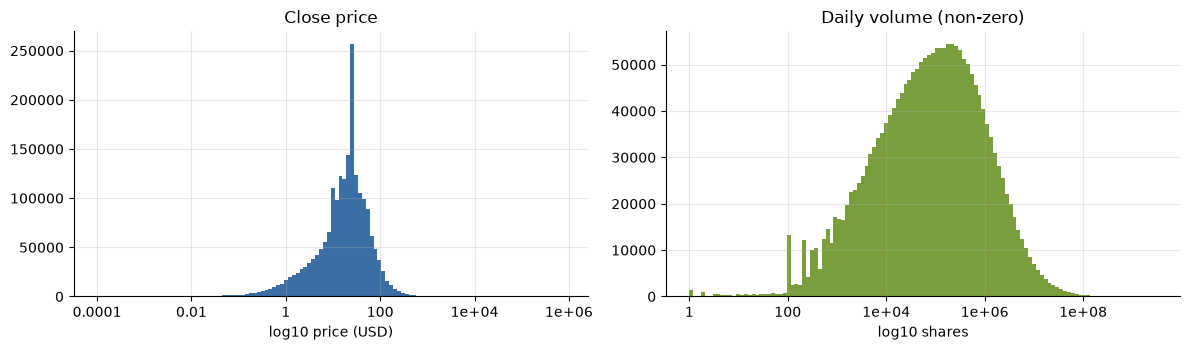

,count,mean,std,min,1%,25%,50%,75%,99%,max
close,46490567.0,63.37013,3333.064759,0.0001,0.21,8.84,20.4296,35.04,222.77,809350.0


In [14]:
sample = day.loc[day["close"] > 0, ["close", "volume"]].sample(2_000_000, random_state=0)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].hist(np.log10(sample["close"]), bins=120, color="#3b6ea5")
ax[0].set_title("Close price"); ax[0].set_xlabel("log10 price (USD)")
ax[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{10**x:,.4g}"))
nz = sample.loc[sample["volume"] > 0, "volume"]
ax[1].hist(np.log10(nz), bins=120, color="#7a9e3b")
ax[1].set_title("Daily volume (non-zero)"); ax[1].set_xlabel("log10 shares")
ax[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{10**x:,.4g}"))
fig.tight_layout(); plt.show()
day["close"].describe(percentiles=[.01, .25, .5, .75, .99]).to_frame("close").T

## 8. Symbols with no reference entry

Every ticker in the price lake should appear in Polygon's tickers reference, and the match has to
be made on the symbol **as spelled** — upper-casing one side is how section 6's bug got in.
The ones that genuinely have no row fall into two groups: exchange **test symbols**, which print
synthetic prices and must be excluded from any analysis of real returns, and class lines
(preferred series, warrants, rights) that the tickers endpoint does not carry.

In [15]:
lake_tickers = pd.Index(day["ticker"].cat.categories)
unknown = lake_tickers.difference(pd.Index(ref["ticker"].unique()))     # both sides spelled as Polygon does
unk_rows = day[day["ticker"].isin(unknown)]
print(f"{len(unknown):,} of {len(lake_tickers):,} lake tickers have no reference row "
      f"({len(unk_rows):,} rows, {len(unk_rows) / len(day):.3%})")
print(f"of those, {sum(t != t.upper() for t in unknown):,} carry a lowercase class letter "
      f"(preferred series, warrants and rights, which the tickers endpoint covers unevenly)")
odd = unk_rows.groupby("ticker", observed=True).agg(rows=("close", "size"), max_close=("close", "max")) \
              .sort_values("max_close", ascending=False).head(10)
print("\nhighest-priced unknown symbols (the classic NYSE/Nasdaq test tickers):")
odd

1,853 of 33,833 lake tickers have no reference row (717,891 rows, 1.544%)
of those, 904 carry a lowercase class letter (preferred series, warrants and rights, which the tickers endpoint covers unevenly)

highest-priced unknown symbols (the classic NYSE/Nasdaq test tickers):


,rows,max_close
ticker,,
ZTEST,2186,499999.995
NTEST.G,30,300010.000
ZBZZT,69,199999.990
ZJZZT,903,199999.990
ZYSZZ,3,199999.990
ZYSTF,9,199999.990
AAZST,137,199999.990
ZVZZT,5508,199999.990
ZWZZT,3655,199999.990


`ZTEST`, `ZVZZT`, `ZXZZT`, `ZWZZT` and friends are exchange test symbols that quote at absurd
prices — half a million dollars in one case. They are excluded from the return analysis below.
The class lines in the rest of the list are a thinner problem: they trade for real, but with no
reference row they cannot be typed, priced against a company, or adjusted.

## 9. Do the adjustments explain the extreme moves?

The sharpest test of a corporate-actions pipeline: take the largest overnight jumps in raw
prices and check that the split-adjusted series removes them. Anything left is either a real
move or a corporate action the splits table does not carry.

In [16]:
real = day[~day["ticker"].isin(unknown)]
liquid = real.loc[real["volume"] * real["close"] > 1e6, ["ticker", "date", "close"]].sort_values(["ticker", "date"])
liquid["prev"] = liquid.groupby("ticker", observed=True)["close"].shift(1)
liquid["raw_gap"] = liquid["close"] / liquid["prev"]
extremes = liquid.loc[liquid["raw_gap"].notna() & ((liquid["raw_gap"] > 4) | (liquid["raw_gap"] < 0.25))].copy()
print(f"{len(extremes):,} overnight gaps beyond 4x or 1/4x on symbols trading over $1 M that day")

adj = read_lake(DAY_ADJ, ["datetime", "ticker", "close_split", "volume", "id"])
adj["date"] = adj["datetime"].dt.tz_localize("UTC").dt.tz_convert("US/Eastern").dt.normalize().dt.tz_localize(None)
adj = adj.sort_values("volume").drop_duplicates(["ticker", "date"], keep="last").sort_values(["ticker", "date"])
adj["prev_split"] = adj.groupby("ticker", observed=True)["close_split"].shift(1)
adj["adj_gap"] = adj["close_split"] / adj["prev_split"]

both = extremes.merge(adj[["ticker", "date", "adj_gap", "id"]], on=["ticker", "date"], how="left")
fixed = both["adj_gap"].between(0.25, 4)
print(f"explained by the split adjustment: {fixed.sum():,} of {len(both):,} ({fixed.mean():.1%})")
both.assign(raw_gap=lambda d: d["raw_gap"].round(2), adj_gap=lambda d: d["adj_gap"].round(3),
            date=lambda d: d["date"].dt.date)[["ticker", "date", "close", "raw_gap", "adj_gap", "id"]] \
    .sort_values("raw_gap", ascending=False).head(12)

4,772 overnight gaps beyond 4x or 1/4x on symbols trading over $1 M that day


explained by the split adjustment: 3,547 of 4,772 (74.3%)


,ticker,date,close,raw_gap,adj_gap,id
1976,COIN,2021-04-14,328.2800,2264.00,2264.000,BBG00ZGF7771
258,CHTR,2010-09-14,35.5000,1775.00,1775.000,BBG000VPGNR2
4600,BETS,2024-01-10,6.6100,1139.66,1.140,CIK__0001543268
2032,VTG,2025-07-16,74.8765,993.06,1.002,BBG01VXRNYQ6
3718,GMBL,2023-12-22,6.9100,658.10,1.645,BBG000Q8H8G0
135,AVR,2006-06-29,38.3700,639.50,767.400,NOFIGI__AVR#SEG1
4752,FMTO,2025-04-22,7.3300,610.83,1.222,BBG017VBWGD9
2436,GMAN,2019-03-19,49.0172,544.64,1.007,CIK__0001479026
1326,VC,2011-01-10,75.6500,504.33,3782.500,BBG0016T3GQ0
103,APP,2021-04-15,65.2000,495.82,580.588,BBG006HFPX77


About three in four extreme gaps vanish once splits are applied. The survivors fall into two
honest categories rather than pipeline faults:

- **First-session artefacts.** A direct listing or a post-bankruptcy relisting prints a
  reference price that is not a tradeable close, so the first real session looks like a
  thousand-fold move. Coinbase on 2021-04-14 and Charter on 2010-09-14 are the clearest cases,
  and both show `raw_gap == adj_gap` because no split is involved.
- **Unresolved micro caps.** Reverse splits that Polygon's splits table does not carry, mostly
  on symbols whose `id` starts with `NOFIGI__`, meaning the security master could not resolve
  the company behind the ticker.

Neither is fixable from the lake alone, but both are easy to exclude: require a minimum price
and a listing history of more than one session before computing returns.

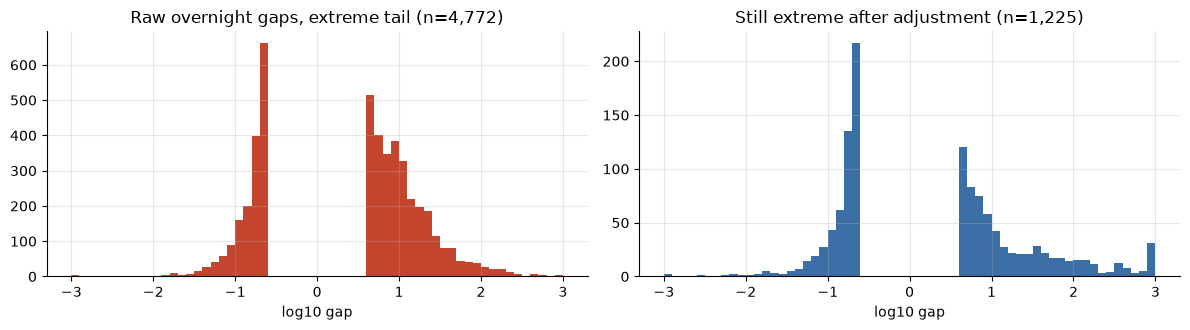

date,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
unexplained gaps,2,9,13,16,70,58,35,33,32,19,...,43,39,65,66,81,119,74,95,143,116


In [17]:
left = both.loc[~fixed].copy()
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].hist(np.log10(both["raw_gap"].clip(1e-3, 1e3)), bins=60, color="#c4462f")
ax[0].set_title(f"Raw overnight gaps, extreme tail (n={len(both):,})"); ax[0].set_xlabel("log10 gap")
ax[1].hist(np.log10(left["adj_gap"].clip(1e-3, 1e3).dropna()), bins=60, color="#3b6ea5")
ax[1].set_title(f"Still extreme after adjustment (n={len(left):,})"); ax[1].set_xlabel("log10 gap")
fig.tight_layout(); plt.show()
left.groupby(left["date"].dt.year).size().rename("unexplained gaps").to_frame().T

## 10. The minute lake, from metadata

7 billion rows is too many to load, and unnecessary: the parquet footers give rows per day,
and the sidecars give per-ticker row counts without touching a data page.

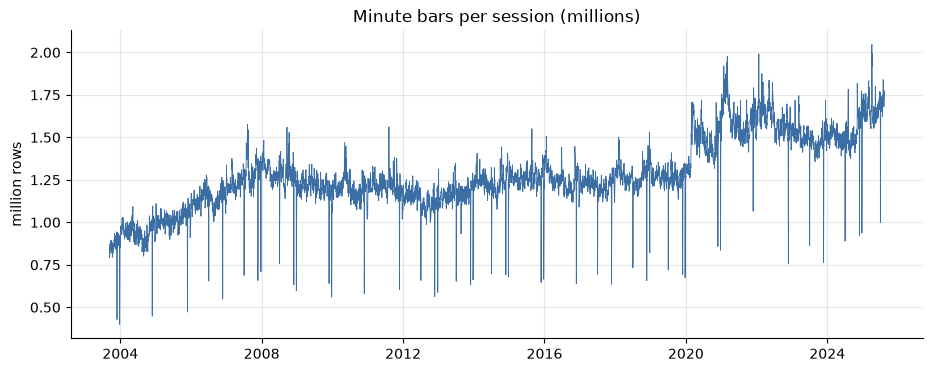

5,517 sessions, 7,042,253,913 rows, 92 GB


,sessions,rows,GB
year,,,
2003,79,"67,569,138",0.6
2004,252,"237,167,836",2.3
2005,252,"256,123,834",2.5
2006,251,"284,748,140",2.9
2007,251,"315,778,466",3.3
2008,253,"326,397,586",3.7
2009,252,"303,233,511",3.6
2010,252,"301,576,295",3.6
2011,252,"305,521,879",3.7


In [18]:
min_files = data_files(MIN_RAW)
meta = pd.DataFrame([{"date": pd.Timestamp(*(int(x) for x in (p.parts[-3], p.parts[-2], p.stem))),
                      "rows": pq.ParquetFile(p).metadata.num_rows,
                      "MB": p.stat().st_size / 2**20} for p in min_files])
meta["year"] = meta["date"].dt.year
fig, ax = plt.subplots()
ax.plot(meta["date"], meta["rows"] / 1e6, lw=.6, color="#3b6ea5")
ax.set_title("Minute bars per session (millions)"); ax.set_ylabel("million rows"); plt.show()
print(f"{len(meta):,} sessions, {meta['rows'].sum():,} rows, {meta['MB'].sum() / 1024:.0f} GB")
meta.groupby("year").agg(sessions=("rows", "size"), rows=("rows", "sum"), GB=("MB", lambda s: round(s.sum() / 1024, 1))) \
    .assign(rows=lambda d: d["rows"].map("{:,}".format))

The step up in 2021 is extended-hours coverage widening, not a change in the pipeline.

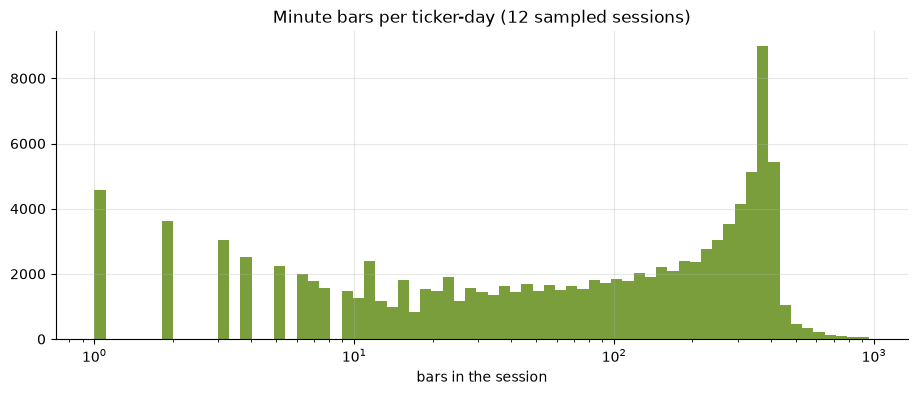

,count,mean,std,min,10%,25%,50%,75%,90%,99%,max
bars per ticker-day,109757.0,147.7,151.9,1.0,3.0,13.0,83.0,280.0,383.0,502.0,960.0


In [19]:
idx = pd.concat([pd.read_parquet(MIN_ADJ / f"{d:%Y/%m/%d}.idx.parquet")
                 for d in meta["date"].sample(12, random_state=3)], keys=range(12), names=["sample"])
fig, ax = plt.subplots()
ax.hist(idx["n_rows"], bins=np.logspace(0, np.log10(idx["n_rows"].max()), 70), color="#7a9e3b")
ax.set_xscale("log"); ax.set_title("Minute bars per ticker-day (12 sampled sessions)")
ax.set_xlabel("bars in the session"); plt.show()
idx["n_rows"].describe(percentiles=[.1, .25, .5, .75, .9, .99]).round(1).to_frame("bars per ticker-day").T

The median symbol prints a few dozen bars a day and the busiest print the full extended
session. A minute lake is mostly sparse: that long left tail is why per-ticker files would
be a bad layout here, and why the market layout plus sidecar wins.

## 11. Summary

In [20]:
summary = pd.DataFrame([
    ("day bars", f"{len(day):,}"),
    ("minute bars", f"{meta['rows'].sum():,}"),
    ("tickers, day lake", f"{len(lake_tickers):,}"),
    ("sessions", f"{len(days):,}"),
    ("date range", f"{day['date'].min():%Y-%m-%d} to {day['date'].max():%Y-%m-%d}"),
    ("crossed or out-of-range bars", f"{int((h < l).sum() + ((c < l) | (c > h)).sum()):,}"),
    ("symbols carrying a lowercase class letter", f"{len(lower):,}"),
    ("duplicate ticker-days (one mis-stamped source file)", f"{len(dups.drop_duplicates(['ticker', 'date'])):,}"),
    ("tickers with no reference row", f"{len(unknown):,}"),
    ("null-ticker minute rows", f"{int(nulls['null_ticker_rows'].sum()) if len(nulls) else 0:,}"),
    ("extreme raw gaps explained by splits", f"{fixed.mean():.1%}"),
], columns=["metric", "value"]).set_index("metric")
summary

,value
metric,
day bars,"46,490,567"
minute bars,"7,042,253,913"
"tickers, day lake","33,833"
sessions,"5,517"
date range,2003-09-10 to 2025-08-13
crossed or out-of-range bars,0
symbols carrying a lowercase class letter,"4,041"
duplicate ticker-days (one mis-stamped source file),28
tickers with no reference row,"1,853"


**Takeaways for anyone using these lakes**

- **Bar-level integrity is sound.** No crossed bars, no non-positive prices, no closes outside
  the day's range, and the trading calendar is exactly right, down to the Ford mourning day and
  the Hurricane Sandy closure.
- **Ticker case is data — never upper-case it.** Polygon spells the share class in the case, so
  `AAp` (Alcoa's preferred) and `AAP` (Advance Auto Parts) are different securities. The lakes
  used to merge about 90 such pairs; they no longer do, and a groupby on the symbol as spelled is
  now correct. Polygon carries no splits or dividends for the preferred and warrant lines, so do
  not read their `close_tr` as a total-return series.
- **One bad source file survives.** 28 ticker-days on 2019-08-13 hold two rows because the
  2019-08-12 flat file was stamped with the next trading day. 56 rows in 46.5 million; keep the
  higher-volume row, as this notebook does.
- **Exclude the test symbols.** 1,853 lake tickers have no reference row, 904 of them class
  lines the tickers endpoint does not carry; the expensive ones are exchange test tickers quoting
  up to $500,000 and they will wreck any return study.
- **Use `close_split` across corporate actions.** It removes about three in four of the extreme
  overnight gaps; the rest are listing-day reference prices and unresolved `NOFIGI__` micro caps,
  both of which a minimum-price and minimum-history filter removes.
- **Never load the minute lake whole.** Parquet footers and the `.idx.parquet` sidecars answer
  most structural questions for free; notebook 06 covers reading it properly.
